<a href="https://colab.research.google.com/github/venugogu6109-spec/RetailPulse-AI-Customer-Analytics/blob/main/RetailPulse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("succesfully libray installed ")

succesfully libray installed 


In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving retail-II.zip to retail-II.zip


In [3]:
import os

print(os.listdir())

['.config', 'retail-II.zip', 'sample_data']


In [6]:
import zipfile

with zipfile.ZipFile("retail-II.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [8]:
import os

print(os.listdir("data"))

['online_retail_II.xlsx']


In [9]:
import pandas as pd

df = pd.read_excel("data/online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

Shape: (525461, 8)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [11]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [12]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [13]:
df["total_price"]=df["Price"]*df["Quantity"]

In [14]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,total_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [21]:
df_qty = df[
    (df["Quantity"] > 0) &
    (df["Quantity"] < 100)
]

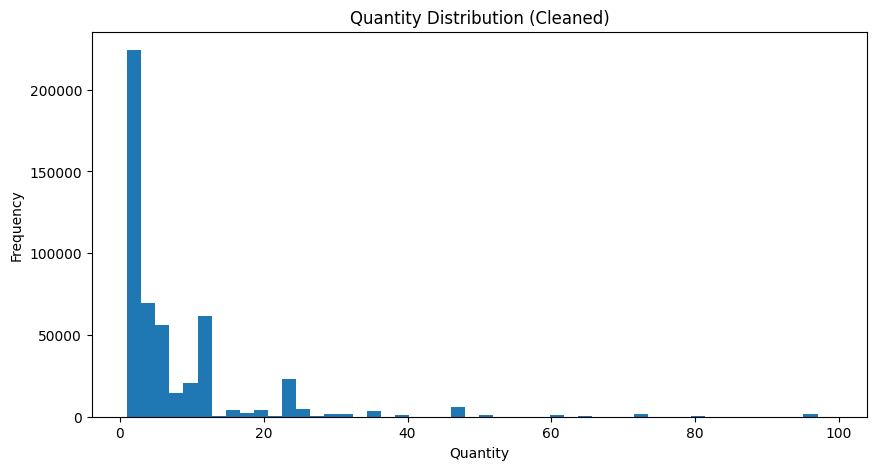

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df_qty["Quantity"],
    bins=50
)

plt.title("Quantity Distribution (Cleaned)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

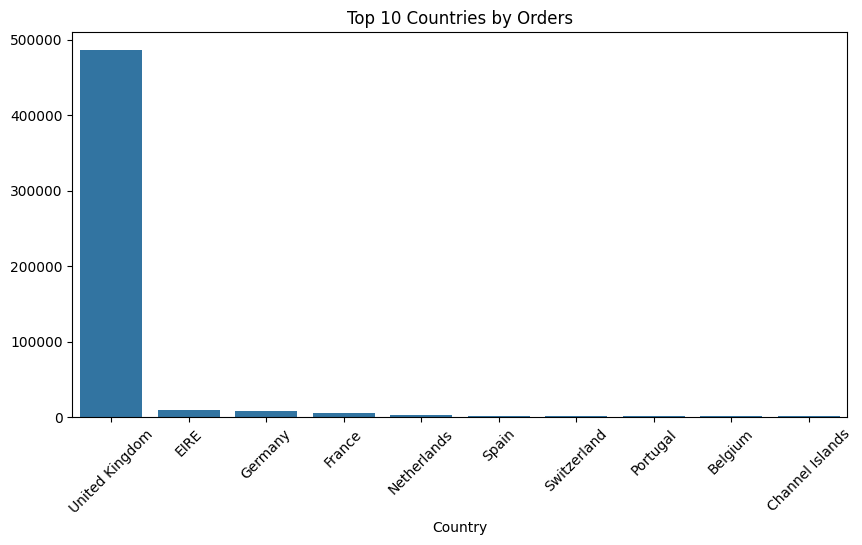

In [23]:
import seaborn as sns

top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Orders")

plt.show()

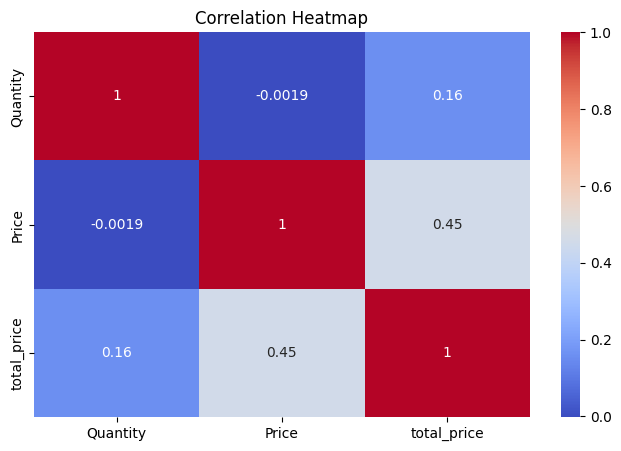

In [19]:
corr = df[["Quantity", "Price", "total_price"]].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [24]:
df_clean = df.dropna(subset=["Customer ID"])

In [25]:
df_clean = df_clean.dropna(subset=["Description"])

In [26]:
df_clean = df_clean[df_clean["Quantity"] > 0]

In [27]:
df_clean = df_clean[df_clean["Price"] > 0]

In [28]:
print(df_clean.shape)

(407664, 9)


In [30]:
df_clean["total_price"]=df_clean["Quantity"]*df_clean["Price"]

In [31]:
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"]
)

In [32]:
snapshot_date = (
    df_clean["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print(snapshot_date)

2010-12-10 20:01:00


In [35]:
rfm = df_clean.groupby(
    "Customer ID"
).agg(
{
    "InvoiceDate":
    lambda x: (
        snapshot_date - x.max()
    ).days,

    "Invoice":
    "nunique",

    "total_price":
    "sum"
}
)

In [36]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [37]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [38]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


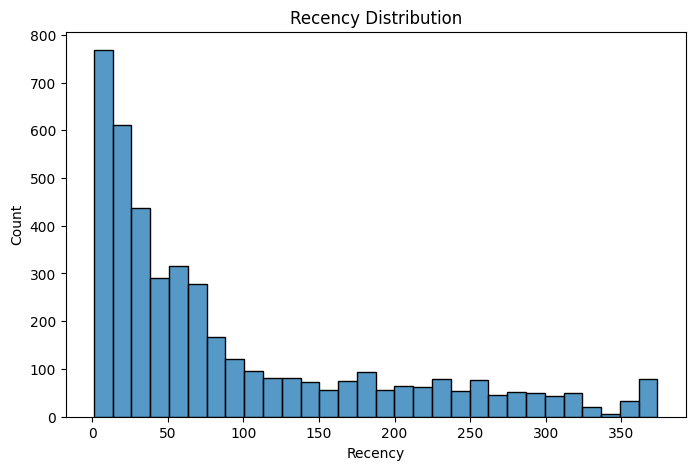

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Recency"],
    bins=30
)

plt.title("Recency Distribution")

plt.show()

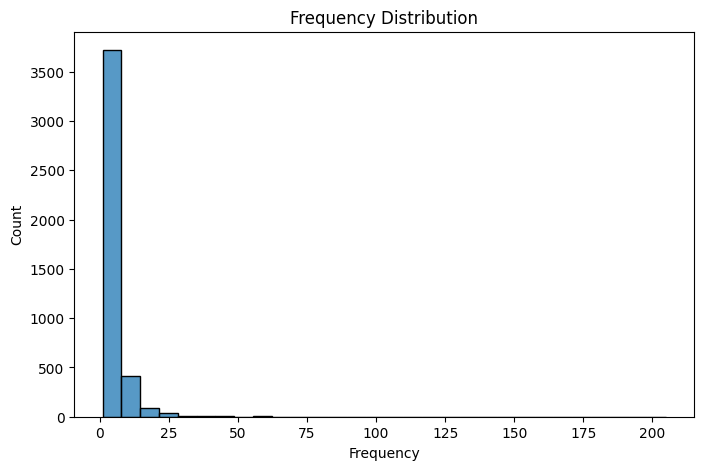

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Frequency"],
    bins=30
)

plt.title("Frequency Distribution")

plt.show()

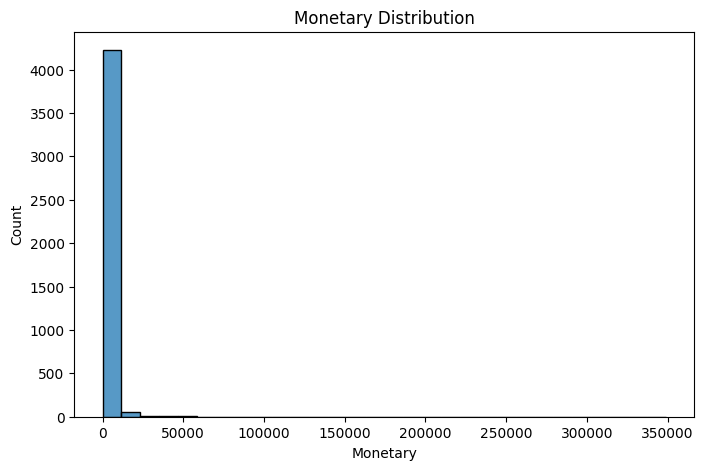

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Monetary"],
    bins=30
)

plt.title("Monetary Distribution")

plt.show()

In [42]:
df_clean.to_csv(
    "clean_retail_data.csv",
    index=False
)

In [43]:
rfm.to_csv(
    "rfm_table.csv"
)

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [45]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [46]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(
        kmeans.inertia_
    )

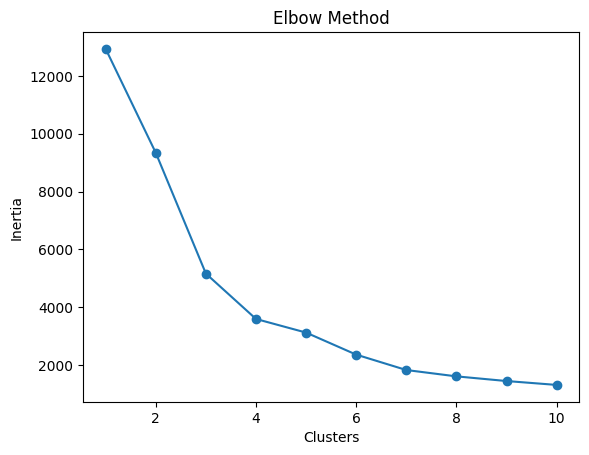

In [47]:
import matplotlib.pyplot as plt

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [48]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

In [50]:
rfm["Cluster"].value_counts()


,count
Cluster,
0,3207
1,1047
3,53
2,5


In [51]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,42.996882,4.469598,1743.129790
1,242.976122,1.659981,596.884493
2,5.600000,113.600000,215543.670000
3,15.433962,48.547170,29040.181566


In [52]:
cluster_names = {
    0: "Regular Customers",
    1: "At Risk Customers",
    2: "Champions",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,165,11,372.86,1,At Risk Customers
12347.0,3,2,1323.32,0,Regular Customers
12348.0,74,1,222.16,0,Regular Customers
12349.0,43,3,2671.14,0,Regular Customers
12351.0,11,1,300.93,0,Regular Customers


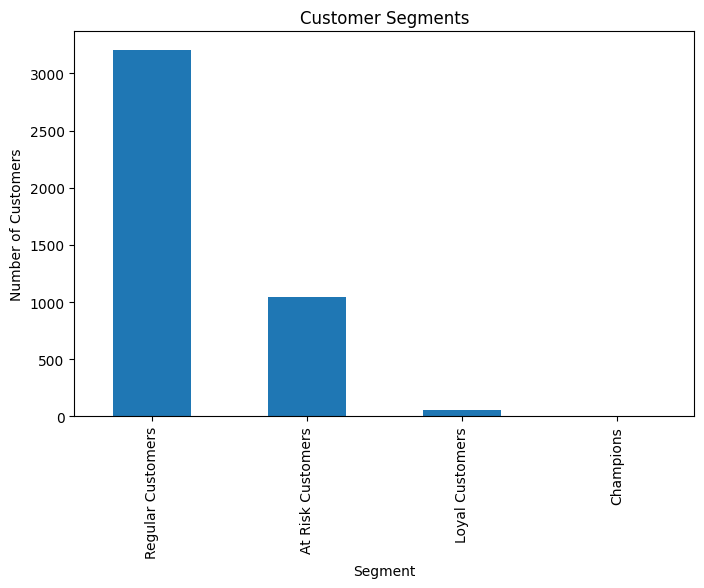

In [53]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.show()

In [54]:
rfm.to_csv(
    "customer_segments.csv"
)

In [55]:
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"]
)

In [57]:
daily_sales = (
    df_clean
    .groupby(
        df_clean["InvoiceDate"].dt.date
    )["total_price"]
    .sum()
    .reset_index()
)

In [58]:
daily_sales.head()

,InvoiceDate,total_price
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


In [60]:
daily_sales.columns = [
    "ds",
    "y"
]

In [61]:
daily_sales.head()

,ds,y
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


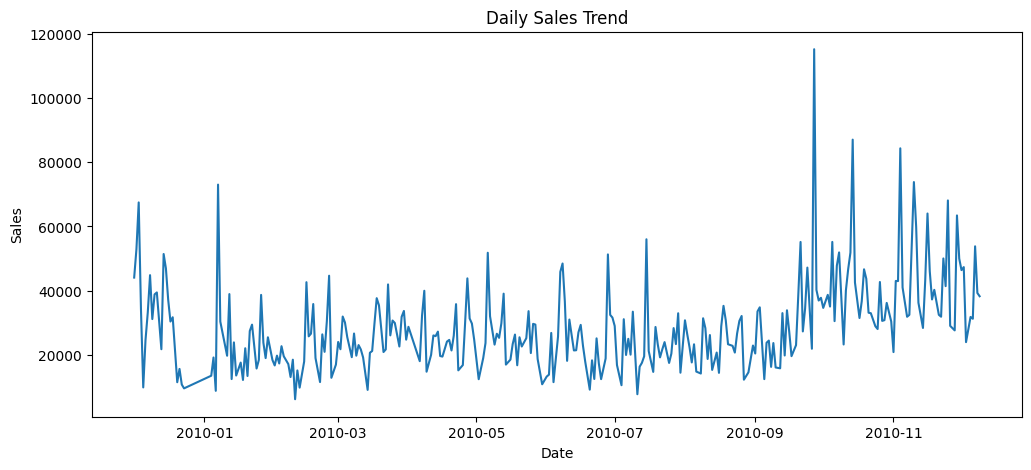

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    daily_sales["ds"],
    daily_sales["y"]
)

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [64]:
monthly_sales = (
    df_clean
    .groupby(
        pd.Grouper(
            key="InvoiceDate",
            freq="M"
        )
    )["total_price"]
    .sum()
    .reset_index()
)

/tmp/ipykernel_1642/3050399822.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


In [65]:
monthly_sales.head()

,InvoiceDate,total_price
0,2009-12-31,686654.160
1,2010-01-31,557319.062
2,2010-02-28,506371.066
3,2010-03-31,699608.991
4,2010-04-30,594609.192


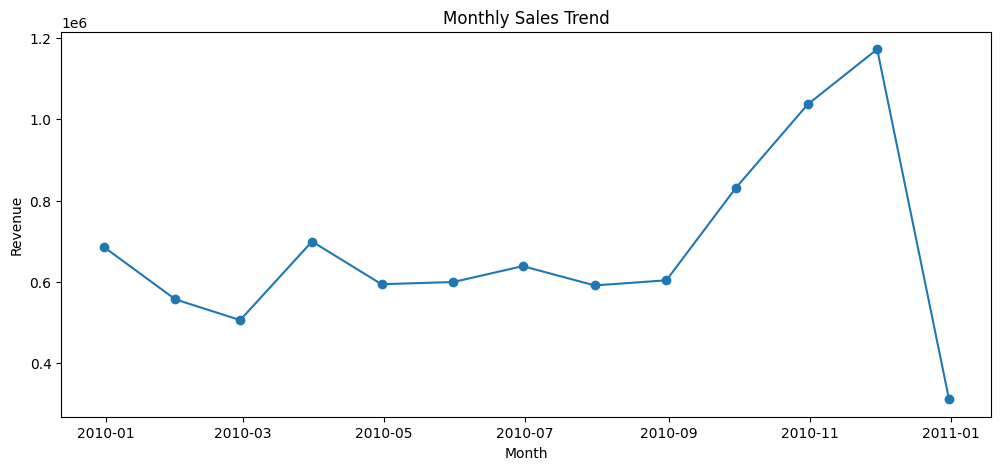

In [67]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["total_price"],
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

In [68]:
daily_sales["Rolling7"] = (
    daily_sales["y"]
    .rolling(7)
    .mean()
)

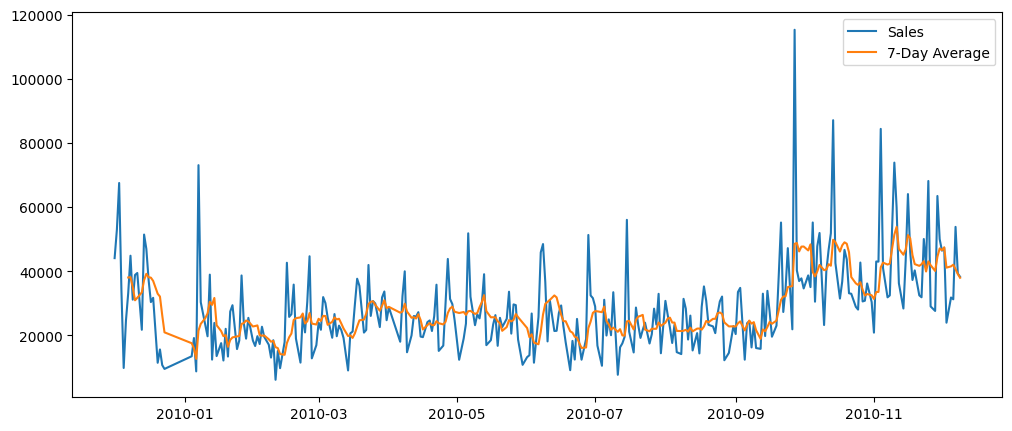

In [69]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_sales["ds"],
    daily_sales["y"],
    label="Sales"
)

plt.plot(
    daily_sales["ds"],
    daily_sales["Rolling7"],
    label="7-Day Average"
)

plt.legend()

plt.show()

In [70]:
monthly_sales["Month"] = (
    monthly_sales["InvoiceDate"]
    .dt.month_name()
)

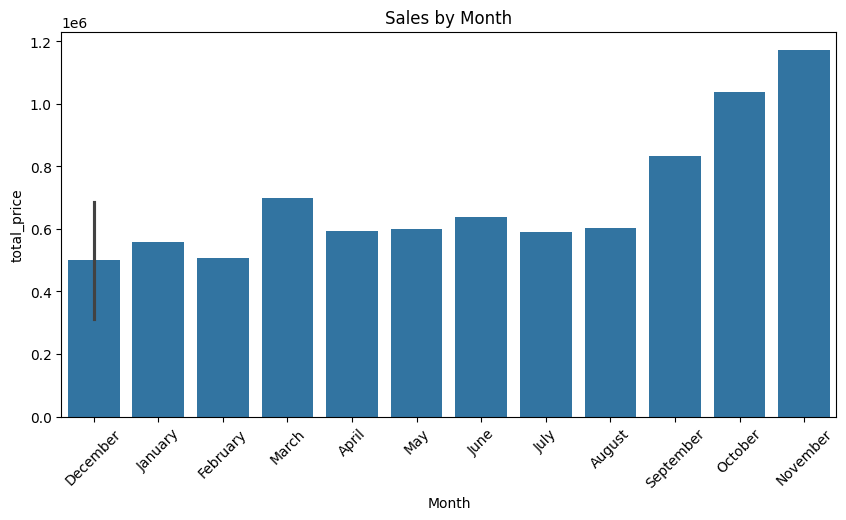

In [71]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly_sales,
    x="Month",
    y="total_price"
)

plt.xticks(rotation=45)

plt.title(
    "Sales by Month"
)

plt.show()

In [74]:
daily_sales.to_csv(
    "forecast_dataset.csv",
    index=False
)

In [73]:
daily_sales.head()

daily_sales.shape

monthly_sales.head()

,InvoiceDate,total_price,Month
0,2009-12-31,686654.160,December
1,2010-01-31,557319.062,January
2,2010-02-28,506371.066,February
3,2010-03-31,699608.991,March
4,2010-04-30,594609.192,April


In [75]:
from prophet import Prophet

In [76]:
daily_sales.head()

,ds,y,Rolling7
0,2009-12-01,44048.69,NaN
1,2009-12-02,52941.99,NaN
2,2009-12-03,67479.08,NaN
3,2009-12-04,34064.41,NaN
4,2009-12-05,9803.05,NaN


In [77]:
import pandas as pd

daily_sales = pd.read_csv("forecast_dataset.csv")

In [79]:
model = Prophet()

model.fit(daily_sales)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [80]:
future = model.make_future_dataframe(
    periods=90
)

In [81]:
future.tail()

,ds
392,2011-03-05
393,2011-03-06
394,2011-03-07
395,2011-03-08
396,2011-03-09


In [82]:
forecast = model.predict(
    future
)

In [83]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,24644.941022,14568.607460,44626.474772,24644.941022,24644.941022,5531.183150,5531.183150,5531.183150,5531.183150,5531.183150,5531.183150,0.0,0.0,0.0,30176.124172
1,2009-12-02,24621.279397,13919.504699,42168.722866,24621.279397,24621.279397,2523.410899,2523.410899,2523.410899,2523.410899,2523.410899,2523.410899,0.0,0.0,0.0,27144.690296
2,2009-12-03,24597.617772,19205.014956,47220.567312,24597.617772,24597.617772,9471.180264,9471.180264,9471.180264,9471.180264,9471.180264,9471.180264,0.0,0.0,0.0,34068.798037
3,2009-12-04,24573.956148,9801.775581,38159.912351,24573.956148,24573.956148,-748.251005,-748.251005,-748.251005,-748.251005,-748.251005,-748.251005,0.0,0.0,0.0,23825.705143
4,2009-12-05,24550.294523,-4245.378049,23622.152980,24550.294523,24550.294523,-14701.920956,-14701.920956,-14701.920956,-14701.920956,-14701.920956,-14701.920956,0.0,0.0,0.0,9848.373567


In [84]:
forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail()

,ds,yhat,yhat_lower,yhat_upper
392,2011-03-05,40355.646086,26022.572257,54757.394011
393,2011-03-06,49380.069487,34397.103459,62694.496433
394,2011-03-07,59104.306749,44056.640710,73303.908896
395,2011-03-08,61033.594696,46103.416273,76854.872414
396,2011-03-09,58174.103945,43681.350840,71350.298158


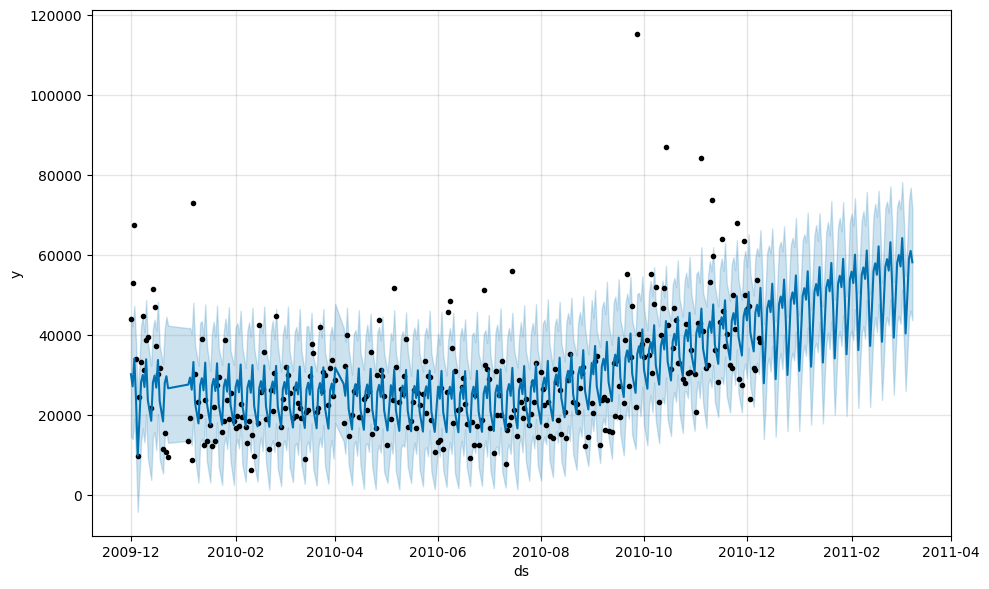

In [85]:
fig = model.plot(
    forecast
)

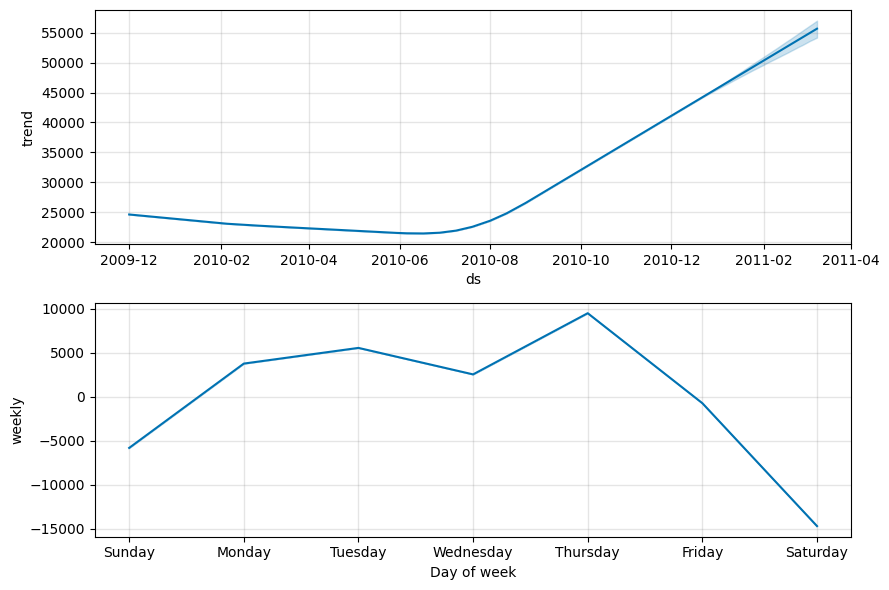

In [86]:
fig2 = model.plot_components(
    forecast
)

In [87]:
forecast_30 = forecast.tail(30)

forecast_30[
    [
        "ds",
        "yhat"
    ]
]

,ds,yhat
367,2011-02-08,56881.712668
368,2011-02-09,54022.221918
369,2011-02-10,61118.272784
370,2011-02-11,51047.123016
371,2011-02-12,37241.734566
372,2011-02-13,46266.157966
373,2011-02-14,55990.395229
374,2011-02-15,57919.683175
375,2011-02-16,55060.192424
376,2011-02-17,62156.243291


In [88]:
forecast.to_csv(
    "sales_forecast.csv",
    index=False
)

In [89]:
df_clean.to_csv("clean_retail_data.csv", index=False)

rfm.to_csv("customer_segments.csv")

forecast.to_csv("sales_forecast.csv", index=False)